In [187]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import os

C1 = '#f5f4b3' #'#3DB2FF' #'#FFAF45'
C2 = '#898|21' #'salmon'  #'#FB6D48'
C3 = '#1f4529'#'green'   #'#D74B76'
C4 = '#abba7c'#'#673F69' #'#673F69'
C5 = '#FFAF45'
C6 = '#bccbf1'

In [301]:
def read_csv_file(filename: str) -> dict:
    d = {}
    with open(filename, 'r') as rd:
        lines= rd.readlines()
        
    header = lines[0]
    header = header.strip().split(',')[1:]
    for line in lines[1:]:
        x = line.strip().split(',')
        if len(x) == 1:
            continue
        workload = x[0]
        for i in range(len(header)):
            if workload not in d:
                d[workload] = {}
            d[workload][header[i]] = float(x[i+1])
    return d

EXCLUDE = []
MPKI_MIN = 0.0
WPKI_MIN = 2.5

def get_stats_for_builds(builds: list[str], stat_name: str, reference_mpki: dict, reference_wpki: dict, mpki_min=MPKI_MIN, wpki_min=WPKI_MIN) -> dict:
    out = {}
    
    for b in builds:
        d = read_csv_file(f'{b}.csv')
        out[b] = { w: stats[stat_name] for (w,stats) in d.items()\
                  if w not in EXCLUDE\
                  and reference_mpki[w] >= mpki_min\
                  and reference_wpki[w] >= wpki_min }
    return out

In [302]:
baseline_stats = read_csv_file('baseline.csv')
reference_mpki = { w: stats['MPKI'] for (w,stats) in baseline_stats.items() }
reference_wpki = { w: stats['WPKI'] for (w,stats) in baseline_stats.items() }
print(reference_mpki)
print(reference_wpki)

{'wrf': 19.3123633530396, 'perlbench': 0.062179974818963014, 'roms': 7.9612973617399385, 'gcc': 17.790500198650935, 'cam4': 5.696124345222295, 'cactubssn': 6.344808617259499, 'exchange2': 8.999999775000006e-05, 'leela': 0.017686246883762916, 'nab': 0.16325369311117074, 'x264': 0.1510587472840596, 'lbm': 33.845200661412775, 'xz': 2.080951208490446, 'imagick': 0.03907874623316926, 'omnetpp': 12.009634047529449, 'pop2': 4.380845906500226, 'bwaves': 17.78632975145166, 'mcf': 15.15385894414091, 'fotonik3d': 18.13528960401769, 'xalancbmk': 1.989119128244725, 'deepsjeng': 0.2956822159235451, 'bfscc': 19.08145972175548, 'triangle': 8.643785277911718, 'pagerankdelta': 19.417117179773125, 'bfs-bitvector': 16.904190700961035, 'components-shortcut': 37.198651199264816, 'radii': 44.80797220984817, 'bc': 25.43994949748232, 'cf': 16.118419755049416, 'mis': 19.360270306050143, 'bfs': 16.74884806464728, 'components': 40.52035347925468, 'pagerank': 36.444133303305904, 'bellmanford': 29.435006178031312, 

In [303]:
def plot_relative_stat(output_file, builds: list[str], stat_name: str, y_label: str, labels: list, color_list: list, negate=False, percentage=False, plot_best_of_all=False):
    stats = get_stats_for_builds(builds, stat_name, reference_mpki=reference_mpki, reference_wpki=reference_wpki)

    n_labels = len(builds)
    if plot_best_of_all:
        n_labels += 1
    
    fig, ax = plt.subplots()
    fig.set_size_inches(12.0, 3.4)

    # Plot stats for each build:
    baseline_ipc_list = stats[builds[0]]
    width = 1.0 / n_labels
    off = 0

    gmean_list = []

    best_of_all = [-100 for _ in baseline_ipc_list]
    workload_order = list(baseline_ipc_list.keys())
    
    for (i, (b, ipc_list)) in enumerate(stats.items()):
        if i == 0:
            continue
        X = np.arange(len(ipc_list)+1)
        
        Y = [ ipc_list[w]/baseline_ipc_list[w] for w in workload_order ]
        best_of_all = [max(max(best_of_all[i], Y[i]), 1.0) for i in range(len(Y))]
        
        Y.append(sp.stats.gmean(Y))
        Y = np.array(Y)
        if percentage:
            Y = (Y-1) * 100
        if negate:
            Y = -Y

        for (ii, w) in enumerate(workload_order):
            print(f'{b}\t{w} speedup: {Y[ii]}')
        print('----------------------------')
            
        gmean_list.append(Y[-1])
        ax.bar(X+off, Y, width, color=color_list[i-1], label=labels[i-1], zorder=3, edgecolor='k')
        off += width

    if plot_best_of_all:
        best_of_all.append(sp.stats.gmean(best_of_all))
        best_of_all = np.array(best_of_all)
        if percentage:
            best_of_all = (best_of_all-1) * 100
        if negate:
            best_of_all = best_of_all

        gmean_list.append(best_of_all[-1])
        ax.bar(X+off, best_of_all, width, color=C6, label='BoA', zorder=3, edgecolor='k')
    
    # Setup anything else that is remaining:
    workload_order.append('gmean')
    
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_xticks(X + (len(builds)-2)/2 * width, workload_order, rotation=30, ha='right', fontsize=12)
    ax.grid(visible=True, axis='y', zorder=0)

    
    ax.legend(fontsize=12, bbox_to_anchor=(0.5,1.25), ncol=n_labels, loc='upper center')
    plt.tight_layout()
    plt.savefig(output_file, bbox_inches='tight')

    # Print out gmeans:
    for (i,b) in enumerate(builds[1:]):
        g = gmean_list[i]
        print(f'{stat_name} GMEAN of {b}\t{g:.3f}')

    if plot_best_of_all:
        print(f'{stat_name} GMEAN of BoA\t{gmean_list[-1]:.3f}')
    print('----------------------------')

wcache	wrf speedup: 0.6005579022609231
wcache	roms speedup: 0.6413013124506817
wcache	cam4 speedup: -0.745756911985429
wcache	lbm speedup: 5.5448488855432965
wcache	omnetpp speedup: 0.2149170866806438
wcache	bwaves speedup: 2.6787849620946824
wcache	fotonik3d speedup: 0.12664258521306593
wcache	triangle speedup: 0.30164348893386705
wcache	pagerankdelta speedup: 1.613585728599265
wcache	radii speedup: 2.4814002858937423
wcache	bc speedup: 3.076912334371862
wcache	cf speedup: 5.217768675391099
wcache	mis speedup: 1.0155876487128124
wcache	pagerank speedup: 1.3046684323721358
wcache	bellmanford speedup: 0.5235719048597431
wcache	scale speedup: 2.1477416095115665
wcache	add speedup: -0.22664724263947722
wcache	copy speedup: 1.918153072938522
wcache	triad speedup: 0.6739467372144814
----------------------------
wcache_soft	wrf speedup: 0.4591041133373386
wcache_soft	roms speedup: 1.072075703411901
wcache_soft	cam4 speedup: -0.7192923318952604
wcache_soft	lbm speedup: 6.3596638258865745
wcac

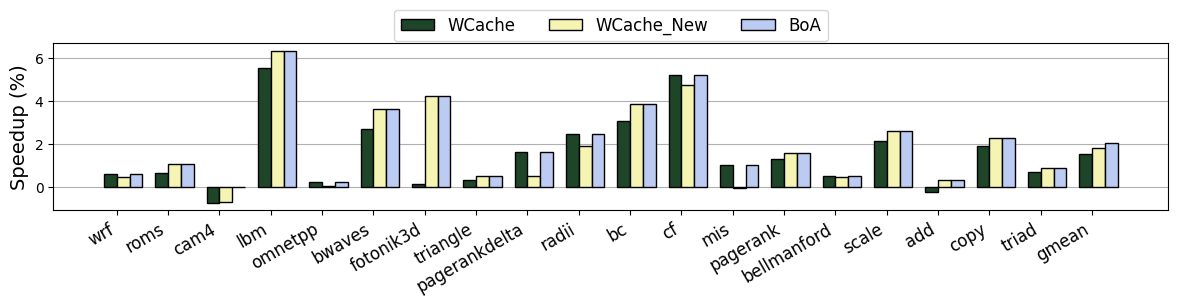

In [307]:
# Main evaluations:
plot_relative_stat('plots/main_evals_lru.pdf',
                   ['baseline', 'wcache', 'wcache_soft'],
                   'IPC',
                   'Speedup (%)',
                   ['WCache', 'WCache_New'],
                   [C3, C1, C4],
                   percentage=True, plot_best_of_all=True)

In [254]:
### LRU SRAM OVERHEADS

LLC_CAPACITY = 16*1024*1024 * 8
LLC_ASSOC = 16
WCACHE_SAMPLED_SETS = 64
DRAM_CHANNELS = 2
DRAM_BANKS = 32

baseline_tagdir_size = (LLC_CAPACITY/(64*8)) * (48-14-6 + 2)

wcache_counters = LLC_ASSOC*8
wcache_mark_registers = LLC_ASSOC*5*WCACHE_SAMPLED_SETS
wcache_bitvec = DRAM_CHANNELS*DRAM_BANKS
wcache_tot = baseline_tagdir_size + wcache_counters + wcache_mark_registers + wcache_bitvec

baseline_bytes = baseline_tagdir_size / 8
wcache_bytes = wcache_tot/ 8

print(wcache_bytes / baseline_bytes)
print(wcache_bytes - baseline_bytes)

1.0006754557291666
664.0


In [78]:
## SRRIP SRAM OVERHEADS
RRIP_BITS=2

wcache_counters = (2**RRIP_BITS)*8
wcache_mark_registers = LLC_ASSOC*5*WCACHE_SAMPLED_SETS
wcache_bitvec = DRAM_CHANNELS*DRAM_BANKS
wcache_tot = baseline_tagdir_size + wcache_counters + wcache_mark_registers + wcache_bitvec

baseline_bytes = baseline_tagdir_size / 8
wcache_bytes = wcache_tot/ 8

print(wcache_bytes / baseline_bytes)
print(wcache_bytes - baseline_bytes)

1.0006632486979166
652.0


In [142]:
## tWRITE calculations
import math

def tWRITE_MISS(freq_ghz: float, CWL: int, BL: int, tWR: float, tRP: int, tRCD: int):
    return (CWL + BL/2 + math.ceil(tWR*freq_ghz) + tRP + tRCD) / freq_ghz

def tROUND_TRIP(freq_ghz: float, tCCD: int, n_banks: int):
    return n_banks * (tCCD/freq_ghz)

## DDR3:
ddr3_twrite_miss = tWRITE_MISS(0.8, 8, 8, 15.0, 11, 11)
ddr3_tround_trip = tROUND_TRIP(0.8, 4, 8)

## DDR5:
ddr5_twrite_miss = tWRITE_MISS(2.4, 38, 16, 30.0, 39, 39)
ddr5_tround_trip = tROUND_TRIP(2.4, 8, 32)

print(f'ddr3 tWRITE_miss = {ddr3_twrite_miss}, tROUND_TRIP = {ddr3_tround_trip}')
print(f'ddr5 tWRITE_miss = {ddr5_twrite_miss}, tROUND_TRIP = {ddr5_tround_trip}')

ddr3 tWRITE_miss = 57.5, tROUND_TRIP = 40.0
ddr5 tWRITE_miss = 81.66666666666667, tROUND_TRIP = 106.66666666666667


In [264]:
### Plot Write RBHR and BLP
write_rbhr_stats = get_stats_for_builds(['baseline'], 'Write RBHR', reference_mpki=reference_mpki, reference_wrr=reference_wrr)['baseline']
write_blp_stats = get_stats_for_builds(['baseline'], 'Write BLP', reference_mpki=reference_mpki, reference_wrr=reference_wrr)['baseline']

for w in write_rbhr_stats:
    print(f'{w:16} &\t {write_rbhr_stats[w]*100 :.1f} &\t {write_blp_stats[w]: .1f} \\\\')

wrf              &	 20.7 &	  16.6 \\
roms             &	 18.2 &	  7.4 \\
cam4             &	 32.7 &	  15.0 \\
lbm              &	 8.7 &	  26.3 \\
omnetpp          &	 0.3 &	  17.5 \\
pop2             &	 22.0 &	  8.9 \\
bwaves           &	 3.3 &	  21.3 \\
fotonik3d        &	 0.7 &	  22.2 \\
triangle         &	 25.6 &	  17.7 \\
pagerankdelta    &	 2.5 &	  22.6 \\
radii            &	 1.6 &	  20.5 \\
bc               &	 30.6 &	  23.3 \\
cf               &	 32.1 &	  19.9 \\
mis              &	 26.6 &	  20.1 \\
pagerank         &	 34.6 &	  19.8 \\
scale            &	 37.8 &	  22.1 \\
add              &	 38.6 &	  21.3 \\
copy             &	 36.3 &	  22.5 \\
triad            &	 38.4 &	  21.3 \\
